# Further TimeSeries Forecasting with ARIMA

In this notebook, we will explore various **SARIMA** models for TimeSeries forecasting. **SARIMA** is a family of models which adds a Seasonality component to the **ARIMA** approach.

With the SARIMA family of models, seven numbers specify how the model runs: $$(p,d,q)\times(P,D,Q)[m]$$

In [72]:
# Import the required packages

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

<AxesSubplot:xlabel='Month'>

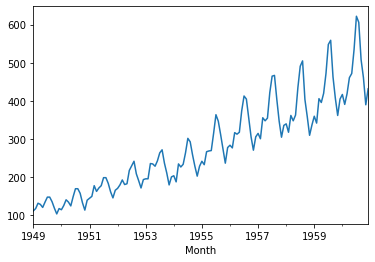

In [73]:
# Read the data and create the TimeSeries

df = pd.read_csv("airline_passengers.csv")
thousand_passengers = df['Thousands of Passengers']

thousand_passengers.index = pd.DatetimeIndex(df['Month'],freq = 'MS')
thousand_passengers.plot()

In [74]:
# Test train split 

train_data =  thousand_passengers[:'1958']
test_data = thousand_passengers['1959':]

### ARIMA(2,2,0)(1,2,0)[12]

In the combined *ARIMA(2,2,0)(1,2,0)* model, we combine all of the methodologies to develop a best fit model. 

We select a second-order autoregressive model with two-times differencing to allow for the data trending upwards and we set seasonal parameters of *(1,2,0)* to allow for an increasing seasonal pattern (spikes getting bigger). Our seasonal period is *12* months.

In [75]:
model_combined = ARIMA(
    train_data,
    order = (2,2,0),
    seasonal_order = (1,2,0,12)    
).fit()
model_combined.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                    SARIMAX Results                                     
========================================================================================
Dep. Variable:          Thousands of Passengers   No. Observations:                  120
Model:             ARIMA(2, 2, 0)x(1, 2, 0, 12)   Log Likelihood                -386.787
Date:                          Fri, 03 Sep 2021   AIC                            781.573
Time:                                  13:22:18   BIC                            791.746
Sample:                              01-01-1949   HQIC                           785.682
                                   - 12-01-1958                                         
Covariance Type:                            opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9173      0.103     -8.914      0.000      -1.119      -0.716
ar.L2         -0.3289      0.091     -3.617      0.000      -0.507      -0.151
ar.S.L12      -0.5867      0.068     -8.603      0.000      -0.720      -0.453
sigma2       206.1573     26.429      7.800      0.000     154.357     257.957
===================================================================================
Ljung-Box (L1) (Q):                   1.02   Jarque-Bera (JB):                 4.17
Prob(Q):                              0.31   Prob(JB):                         0.12
Heteroskedasticity (H):               0.55   Skew:                            -0.37
Prob(H) (two-sided):                  0.10   Kurtosis:                         3.71
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<AxesSubplot:xlabel='Month'>

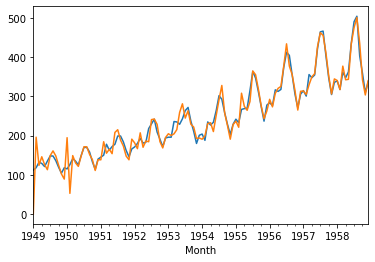

In [76]:
## Plot the training data and the model fitted values

train_data.plot()
model_combined.fittedvalues.plot() 

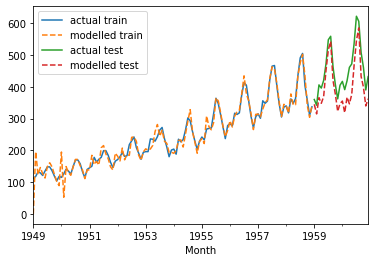

In [77]:
train_data.plot()
model_combined.fittedvalues.plot(style='--')
test_data.plot()
model_combined.forecast(len(test_data)).plot(style='--')
plt.legend(['actual train','modelled train','actual test','modelled test'])

In [78]:
# Average Squared Error for the train_data

squared_errors = (train_data - model_combined.fittedvalues)**2
ase_train = squared_errors.sum()

In [79]:
# Average Squared Error for the test_data

squared_errors = (test_data - model_combined.forecast(len(test_data)))**2
ase_test = squared_errors.sum()

In [85]:
print('---')
print('ARIMA(2,2,0)(1,2,0)[12]')
print('\t Train ASE:',format(ase_train, ",.0f"))
print('\t Test ASE:', format(ase_test, ",.0f"))

---
ARIMA(2,2,0)(1,2,0)[12]
	 Train ASE: 54,586
	 Test ASE: 78,780


For this model, we now have *4 parameters* and only *120 - 12 = 108 data point*. For a model to be robust, we require at least around *30 data points per parameter* but here we have about 27.

At this point, we would make a trade-off between accuracy and robustness of the model.

Choosing the correct hyperparameters for an ARIMA (or SARIMA) model is a big task. There are patterns we can recognise that will help, but eventually some experimentation is required. In the next notebook, we will explore the Auto-ARIMA function.

Research Task: The auto-ARIMA function chooses the best model based on the **Akaike Information Criteria (AIC)**. What does this criterion measure?